                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

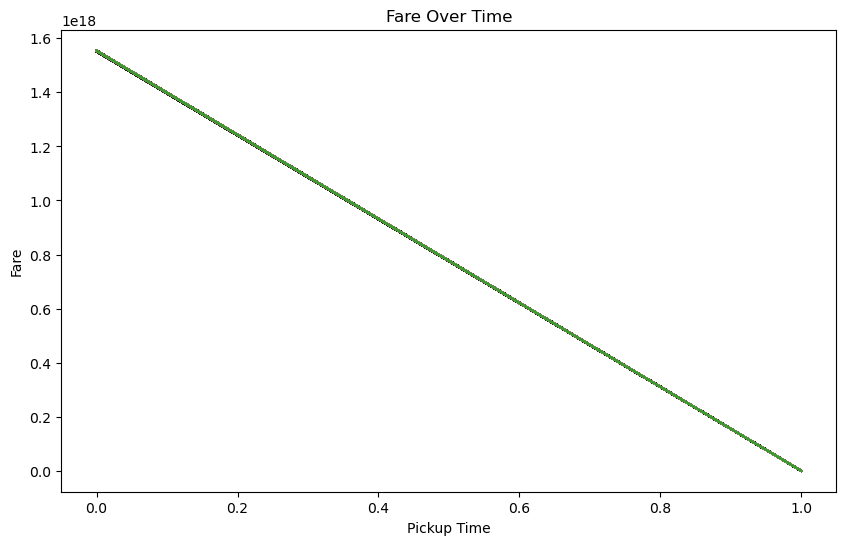

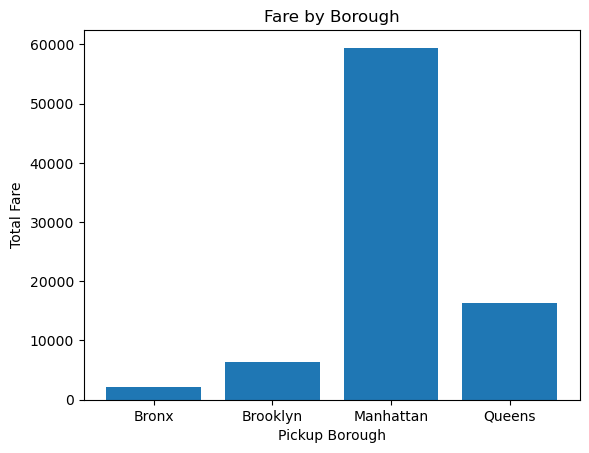

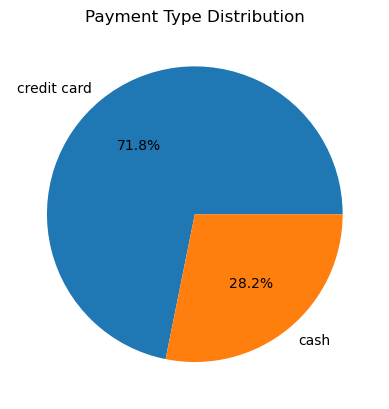

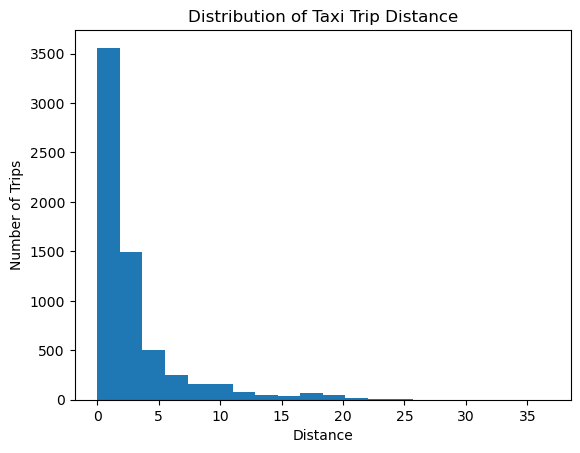

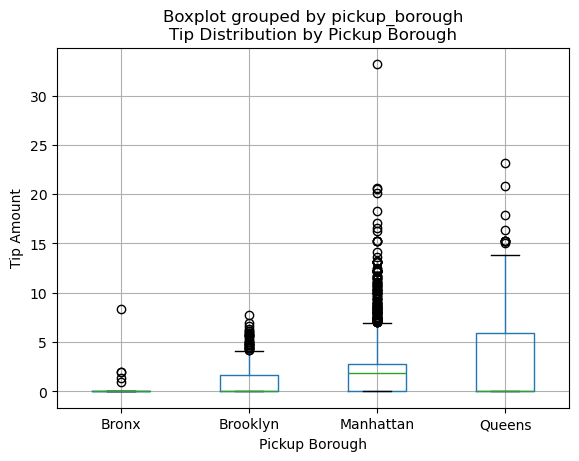

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) Loading the Taxis Dataset
df = sns.load_dataset("taxis")
print(df)

# 2) Handling Missing Values
df.info()

print(df.isnull().sum())

num_cols = df.select_dtypes(include=["number"]).columns

cat_cols = df.select_dtypes(include=["object"]).columns

print(num_cols)
print(cat_cols)

for num in num_cols:
    df[num] = df[num].fillna(df[num].median())

for cat in cat_cols:
    df[cat] = df[cat].fillna(df[cat].mode()[0])

print(df.isnull().sum())

print(df.describe())
print(df.head())

# 3) Visualizations using Matplotlib/Pandas Plot:

# ★ Line Chart
df["pickup"] = pd.to_datetime(df["pickup"])

df = df.sort_values("pickup")

plt.figure(figsize=[10,6])

plt.plot([df["pickup"], df["fare"]])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.show()

# ★ Bar Chart
borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.bar(borough_fare.index, borough_fare.values)
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Fare by Borough")
plt.show()


# ★ Pie Chart
payment_counts = df["payment"].value_counts()
plt.pie(payment_counts.values,labels =payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Type Distribution")
plt.show()


# ★ Histogram
plt.hist(df["distance"], bins=20)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Trip Distance")

plt.show()


# ★ Box Plot
df.boxplot(column="tip", by="pickup_borough")

plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.title("Tip Distribution by Pickup Borough")

plt.show()

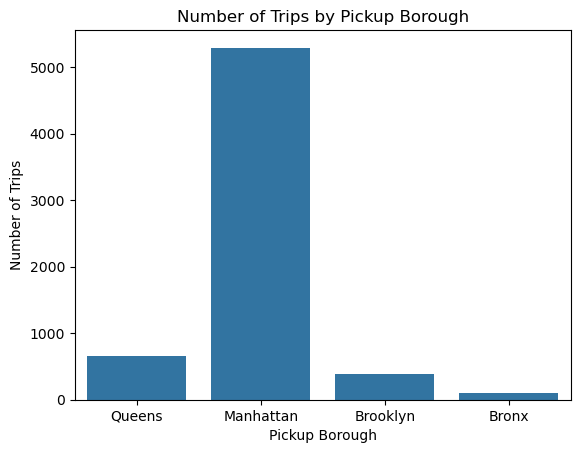

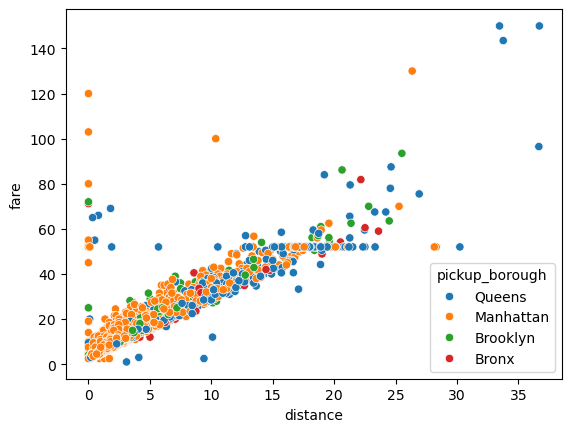

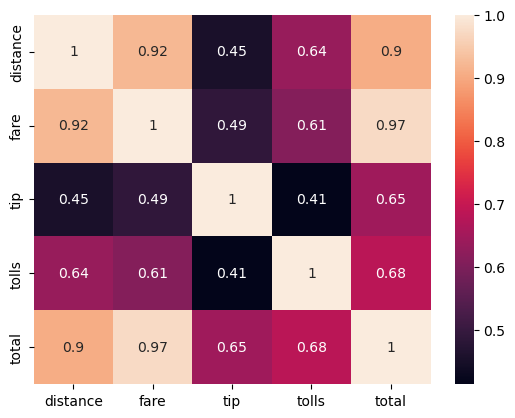

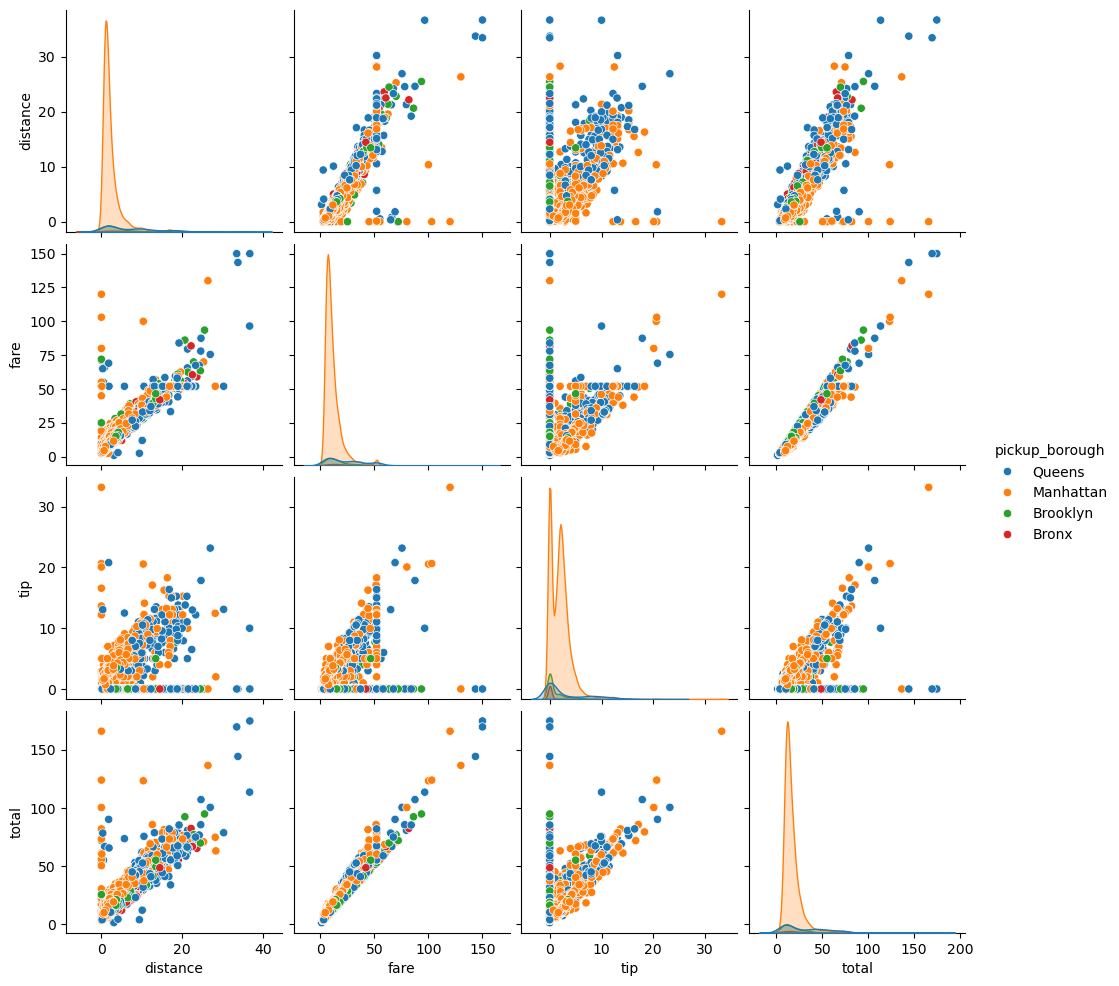

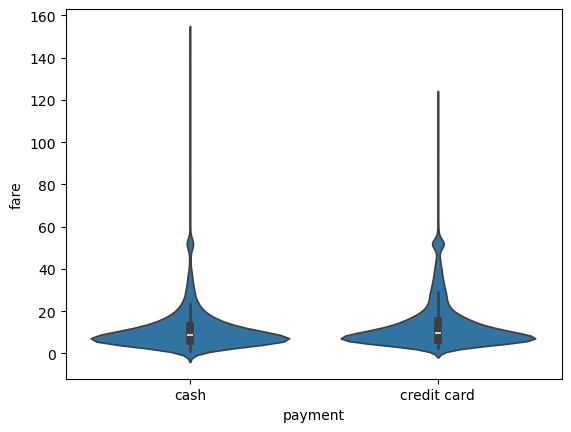

In [22]:
# Visualizations using Seaborn:

# 1. Count Plot

sns.countplot(x="pickup_borough", data=df)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")

plt.show()

# scatter plot

sns.scatterplot(x = "distance",y = "fare", hue="pickup_borough",data =  df)
plt.show()

# heat map

correlation = df[["distance", "fare", "tip", "tolls", "total"]].corr()
sns.heatmap(correlation, annot = True)
plt.show()

# pair plot

vars = ["distance", "fare", "tip", "total"]

sns.pairplot(vars = vars, hue = "pickup_borough", data = df)
plt.show()

#voilon plot

sns.violinplot(x="payment", y="fare", data = df)
plt.show()
